In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor
from sklearn.linear_model import ElasticNet, Ridge
import matplotlib.pyplot as plt



def crear_features_equipo1(df):
    data = df.copy()
    # Lags validados por AIC/Granger
    data["Z_lag1"] = data["Price_Z"].shift(1)
    data["Z_lag2"] = data["Price_Z"].shift(2)
    data["X_lag1"] = data["Price_X"].shift(1)
    data["X_lag2"] = data["Price_X"].shift(2)

    # Memoria semestral (rolling mean ex-ante)
    data["Z_mean_6m"] = data["Price_Z"].rolling(window=6).mean().shift(1)

    # Autoregresivo propio
    data["Eq1_lag1"] = data["Price_Equipo1"].shift(1)

    return data.dropna()


def crear_features_equipo2(df):
    data = df.copy()
    # Transmisión instantánea (Lag 0 contemporáneo)
    data["Z_lag0"] = data["Price_Z"]
    data["Y_lag0"] = data["Price_Y"]

    # Autoregresivo propio para estabilizar pronóstico
    data["Eq2_lag1"] = data["Price_Equipo2"].shift(1)

    return data.dropna()

In [8]:
def preparar_matrices(df_features, target_col, train_ratio=0.70):
    # 1. Split Cronológico 70/30
    n_train = int(len(df_features) * train_ratio)

    train_data = df_features.iloc[:n_train]
    test_data = df_features.iloc[n_train:]

    X_train = train_data.drop(
        columns=["Price_Equipo1", "Price_Equipo2", "Price_X", "Price_Y", "Price_Z"],
        errors="ignore",
    )
    y_train = train_data[target_col]

    X_test = test_data[X_train.columns]
    y_test = test_data[target_col]

    # 2. Escalado fit sobre Train / transform en Train y Test
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test), columns=X_test.columns, index=X_test.index
    )

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

In [9]:
def evaluar_metricas(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {"RMSE": rmse, "MAE": mae, "MAPE (%)": mape, "MSE": mse}


def validacion_cruzada_ts(modelo, X_train, y_train, n_splits=3):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    mapes = []

    for train_idx, val_idx in tscv.split(X_train):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

        modelo.fit(X_tr, y_tr)
        preds = modelo.predict(X_val)
        mapes.append(mean_absolute_percentage_error(y_val, preds) * 100)

    return np.mean(mapes)

In [5]:
# Cargar desde la carpeta raíz del proyecto
df_mensual = pd.read_parquet("../data/processed/df_mensual.parquet")

print("Dimensiones de df_mensual:", df_mensual.shape)
df_mensual.head(2)

Dimensiones de df_mensual: (164, 5)


,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
2010-01-31,77.013,547.0,2234.325,451.8180,945.1895
2010-02-28,74.790,538.0,2048.575,444.1435,886.5750


In [10]:
# Elegir equipo a evaluar (cambiar a crear_features_equipo2 y "Price_Equipo2" para el otro)
df_features_eq1 = crear_features_equipo1(df_mensual)
X_train, X_test, y_train, y_test, scaler = preparar_matrices(
    df_features_eq1, target_col="Price_Equipo1", train_ratio=0.70
)

# Diccionario de modelos candidatos
modelos = {
    "Ridge (Baseline ARDL)": Ridge(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
    "LightGBM": LGBMRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        verbose=-1,
    ),
}

# Ejecutar Benchmark
resultados_benchmark = []

for nombre, modelo in modelos.items():
    # 1. Validación Cruzada Temporal en Train
    mape_cv = validacion_cruzada_ts(modelo, X_train, y_train, n_splits=3)

    # 2. Entrenamiento en todo Train y evaluación en Test (70/30)
    modelo.fit(X_train, y_train)
    preds_test = modelo.predict(X_test)

    metricas = evaluar_metricas(y_test, preds_test)
    metricas["Modelo"] = nombre
    metricas["CV Train MAPE (%)"] = mape_cv

    resultados_benchmark.append(metricas)

# Tabla final ordenada por el menor MAPE en Test
df_benchmark = pd.DataFrame(resultados_benchmark)[
    ["Modelo", "MAPE (%)", "RMSE", "MAE", "MSE", "CV Train MAPE (%)"]
].sort_values(by="MAPE (%)")

print("=" * 80)
print("📊 BENCHMARK DE MODELOS - PRESIÓN DE ERROR EN TEST (HOLD OUT 30%)")
print("=" * 80)
display(df_benchmark)

📊 BENCHMARK DE MODELOS - PRESIÓN DE ERROR EN TEST (HOLD OUT 30%)


,Modelo,MAPE (%),RMSE,MAE,MSE,CV Train MAPE (%)
1,ElasticNet,4.542060,34.630497,24.563105,1199.271342,4.714856
0,Ridge (Baseline ARDL),4.625396,35.372668,25.053586,1251.225658,5.342962
2,LightGBM,11.331202,93.387339,67.730655,8721.195035,23.645123


In [19]:
# Elegir equipo a evaluar (cambiar a crear_features_equipo2 y "Price_Equipo2" para el otro)
df_features_eq1 = crear_features_equipo1(df_mensual)
X_train, X_test, y_train, y_test, scaler = preparar_matrices(
    df_features_eq1, target_col="Price_Equipo2", train_ratio=0.70
)

# Diccionario de modelos candidatos
modelos = {
    "Ridge (Baseline ARDL)": Ridge(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
    "LightGBM": LGBMRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        verbose=-1,
    ),
}

# Ejecutar Benchmark
resultados_benchmark = []

for nombre, modelo in modelos.items():
    # 1. Validación Cruzada Temporal en Train
    mape_cv = validacion_cruzada_ts(modelo, X_train, y_train, n_splits=3)

    # 2. Entrenamiento en todo Train y evaluación en Test (70/30)
    modelo.fit(X_train, y_train)
    preds_test = modelo.predict(X_test)

    metricas = evaluar_metricas(y_test, preds_test)
    metricas["Modelo"] = nombre
    metricas["CV Train MAPE (%)"] = mape_cv

    resultados_benchmark.append(metricas)

# Tabla final ordenada por el menor MAPE en Test
df_benchmark = pd.DataFrame(resultados_benchmark)[
    ["Modelo", "MAPE (%)", "RMSE", "MAE", "MSE", "CV Train MAPE (%)"]
].sort_values(by="MAPE (%)")

print("=" * 80)
print("📊 BENCHMARK DE MODELOS - PRESIÓN DE ERROR EN TEST (HOLD OUT 30%)")
print("=" * 80)
display(df_benchmark)

📊 BENCHMARK DE MODELOS - PRESIÓN DE ERROR EN TEST (HOLD OUT 30%)


,Modelo,MAPE (%),RMSE,MAE,MSE,CV Train MAPE (%)
1,ElasticNet,3.993421,55.783676,41.639266,3111.818541,3.743626
0,Ridge (Baseline ARDL),4.029981,56.054193,41.974599,3142.072510,3.762097
2,LightGBM,7.879549,134.315375,88.795708,18040.619891,14.683576


# Predicciones del Modelo

📊 VISTA PREVIA: REAL VS. PREDICHO EN EL CONJUNTO DE TEST (30% HOLDOUT)


,Precio Real,Predicción (ElasticNet),Error Absoluto ($),Error Relativo (%)
2019-09-30,382.360000,390.880103,8.520103,2.228294
2019-10-31,365.518696,383.801029,18.282333,5.001750
2019-11-30,367.918095,362.982705,4.935390,1.341437
2019-12-31,390.537727,373.994485,16.543242,4.236016
2020-01-31,406.061739,392.342331,13.719408,3.378651
2023-04-30,503.731500,515.808035,12.076535,2.397415
2023-05-31,457.468696,506.744119,49.275423,10.771321
2023-06-30,449.975909,450.699515,0.723606,0.160810
2023-07-31,460.872381,443.696369,17.176012,3.726848
2023-08-31,461.035217,459.691134,1.344083,0.291536


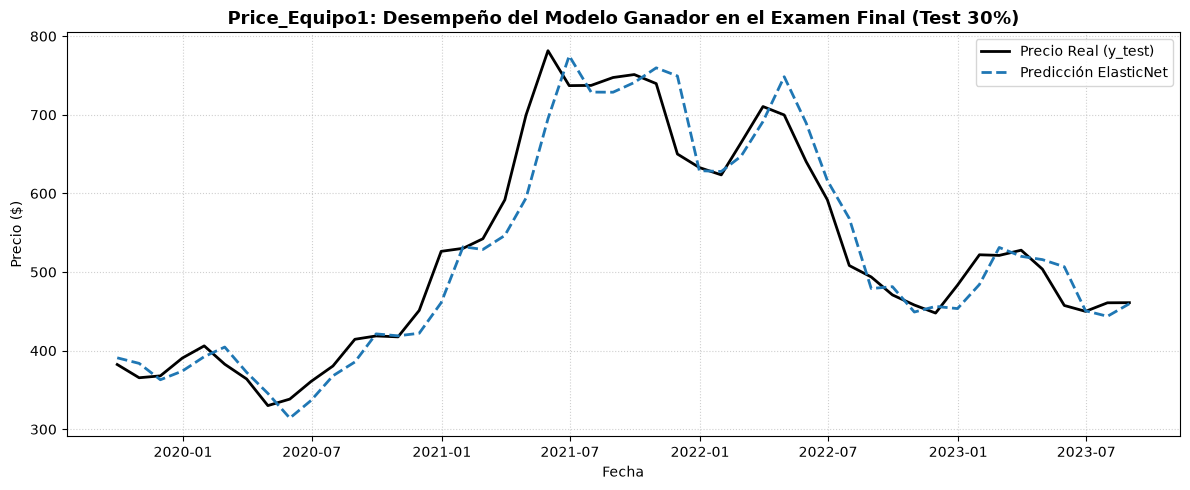


🔍 IMPORTANCIA DE VARIABLES (PESOS ELASTICNET):
 * Un coeficiente más alto significa mayor impacto en el pronóstico *


,Coeficiente (Peso)
Eq1_lag1,85.585450
Z_lag1,21.704515
X_lag2,-14.783957
X_lag1,14.556918
Z_lag2,-10.305895
Z_mean_6m,-6.875247


In [17]:
# ==============================================================================
# 1. GENERAR PREDICCIONES CON EL MODELO GANADOR (ELASTICNET)
# ==============================================================================
modelo_ganador = modelos["ElasticNet"]
preds_test = modelo_ganador.predict(X_test)

# Construir tabla comparativa mes a mes sobre el 30% Test
df_predicciones = pd.DataFrame(
    {
        "Precio Real": y_test,
        "Predicción (ElasticNet)": preds_test,
        "Error Absoluto ($)": abs(y_test - preds_test),
        "Error Relativo (%)": (abs(y_test - preds_test) / y_test) * 100,
    },
    index=y_test.index,
)

print("=" * 85)
print(
    "📊 VISTA PREVIA: REAL VS. PREDICHO EN EL CONJUNTO DE TEST (30% HOLDOUT)"
)
print("=" * 85)
# Mostramos los primeros 5 y últimos 5 meses del periodo de prueba
display(pd.concat([df_predicciones.head(5), df_predicciones.tail(5)]))

# ==============================================================================
# 2. GRÁFICO DE INSPECCIÓN: ¿CÓMO SIGUE LA TENDENCIA?
# ==============================================================================
plt.figure(figsize=(12, 5))
plt.plot(
    df_predicciones.index,
    df_predicciones["Precio Real"],
    label="Precio Real (y_test)",
    color="black",
    linewidth=2,
)
plt.plot(
    df_predicciones.index,
    df_predicciones["Predicción (ElasticNet)"],
    label="Predicción ElasticNet",
    color="#1f77b4",
    linestyle="--",
    linewidth=2,
)

plt.title(
    "Price_Equipo1: Desempeño del Modelo Ganador en el Examen Final (Test 30%)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Fecha")
plt.ylabel("Precio ($)")
plt.legend(frameon=True)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# ==============================================================================
# 3. INTERPRETACIÓN ECONÓMICA: COEFICIENTES DEL MODELO
# ==============================================================================
# Como escalamos con StandardScaler, el tamaño absoluto del coeficiente indica su importancia
coeficientes = pd.Series(
    modelo_ganador.coef_, index=X_train.columns
).sort_values(key=abs, ascending=False)

print("\n🔍 IMPORTANCIA DE VARIABLES (PESOS ELASTICNET):")
print(" * Un coeficiente más alto significa mayor impacto en el pronóstico *")
display(coeficientes.to_frame(name="Coeficiente (Peso)"))

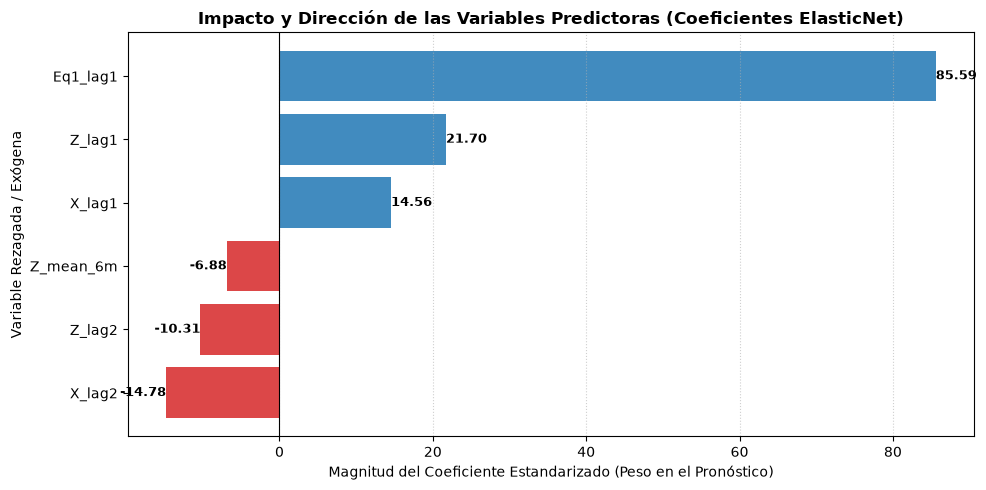

In [18]:
# 1. Preparar datos de coeficientes ordenados de menor a mayor para el gráfico
coefs_sorted = coeficientes.sort_values(ascending=True)
colores = ["#d62728" if c < 0 else "#1f77b4" for c in coefs_sorted.values]

# 2. Crear gráfico de barras horizontales
plt.figure(figsize=(10, 5))
bars = plt.barh(coefs_sorted.index, coefs_sorted.values, color=colores, alpha=0.85)

# 3. Línea vertical de referencia en el origen 0
plt.axvline(x=0, color="black", linestyle="-", linewidth=0.8)

plt.title(
    "Impacto y Dirección de las Variables Predictoras (Coeficientes ElasticNet)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Magnitud del Coeficiente Estandarizado (Peso en el Pronóstico)")
plt.ylabel("Variable Rezagada / Exógena")
plt.grid(axis="x", linestyle=":", alpha=0.6)

# 4. Etiquetar valores al extremo de las barras
for bar in bars:
    width = bar.get_width()
    offset = 0.5 if width >= 0 else -0.5
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        ha="left" if width >= 0 else "right",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()